## Lightweight Segmentation with a MobileNet Encoder-Decoder network

## Setup

In [1]:
# =========================
# 1) IMPORTS
# =========================
import os, time, glob
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import cv2
import albumentations as A
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

import segmentation_models_pytorch as smp

In [3]:
# =========================
# 2) CONFIG 
# =========================
# Root with images/{train,eval,test}
SPLITS_DIR = "../Data/training_set/slz_out/det_obb/splits_yolo_obb"
TRAIN_IMAGES_DIR = os.path.join(SPLITS_DIR, "images", "train")
VAL_IMAGES_DIR   = os.path.join(SPLITS_DIR, "images", "val")   # <- use "eval" as validation
TEST_IMAGES_DIR = os.path.join(SPLITS_DIR, "images", "test")

LEVELS_SEG = False # wheter we are segmenting safety levels directly or segmenting the classes

if LEVELS_SEG:
    MASKS_DIR = "../Data/training_set/slz_out/masks_levels/"
    CLASS_CSV = "../Data/training_set/slz_out/class_dict.csv"
else:
    # Integer (CID) masks, one flat directory with <stem>.png
    MASKS_DIR  = "../Data/training_set/slz_out/masks_cls/"
    # CSV whose row order defines cid (0..N-1)
    CLASS_CSV  = "../Data/training_set/gt/semantic/class_dict.csv"

# I/O + training params
OUTPUT_DIR   = "checkpoints_unet_mobilenet"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_H, IMG_W = 704, 1056
BATCH_SIZE   = 3
EPOCHS       = 100
MAX_LR       = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0 #min(8, os.cpu_count() or 4)

# ImageNet normalization
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

In [4]:
# =========================
# 3) UTILITIES
# =========================
def list_images(folder):
    """Collect .jpg images in a folder. Change pattern if needed."""
    return sorted(glob.glob(os.path.join(folder, "*.jpg")))  # change to *.png etc. if needed

def load_class_names(csv_path):
    """Return (class_names, ignore_index, unlabeled_index) from CSV row order."""
    df = pd.read_csv(csv_path, skipinitialspace=True)
    df.columns = [c.strip().lower() for c in df.columns]
    assert {"name","r","g","b"}.issubset(df.columns), "CSV must have name,r,g,b"
    names = [str(x).strip() for x in df["name"].tolist()]
    ignore_index   = names.index("conflicting") if "conflicting" in names else None
    unlabeled_index = names.index("unlabeled") if "unlabeled" in names else 0
    return names, ignore_index, unlabeled_index

def build_items_from_dir(img_dir, masks_dir):
    """
    Build list of {'id','img','mask'} by pairing images in img_dir with <stem>.png in masks_dir.
    """
    images = list_images(img_dir)
    items, missing = [], []
    for img_path in images:
        stem = os.path.splitext(os.path.basename(img_path))[0]

        if LEVELS_SEG:
            mask_path = os.path.join(masks_dir, stem + "_levels.png")
        else:
            mask_path = os.path.join(masks_dir, stem + ".png")

        if os.path.exists(img_path) and os.path.exists(mask_path):
            items.append({"id": stem, "img": img_path, "mask": mask_path})
        else:
            missing.append((img_path, mask_path))
    if missing:
        print(f"[warn] {len(missing)} samples missing image or mask — skipped. Examples:", missing[:3])
    return items

class_names, IGNORE_IDX, UNLABELED_IDX = load_class_names(CLASS_CSV)
N_CLASSES = len(class_names)
print("Classes:", class_names)
print("Ignore index:", IGNORE_IDX, "(conflicting)" if IGNORE_IDX is not None else "")

Classes: ['unlabeled', 'paved-area', 'dirt', 'grass', 'gravel', 'water', 'rocks', 'pool', 'vegetation', 'roof', 'wall', 'window', 'door', 'fence', 'fence-pole', 'person', 'dog', 'car', 'bicycle', 'tree', 'bald-tree', 'ar-marker', 'obstacle', 'conflicting']
Ignore index: 23 (conflicting)


In [5]:
# =========================
# 4) DATASET (integer masks)
# =========================
class SemanticDatasetCID(Dataset):
    """
    - Reads RGB image
    - Reads integer mask (CID per pixel), no color mapping needed
    - Applies Albumentations transforms (bilinear for image, nearest for mask)
    - Normalizes image with ImageNet mean/std
    """
    def __init__(self, items, mean, std, transform=None):
        self.items = items
        self.transform = transform
        self.img_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        rec = self.items[idx]

        # Image (RGB)
        img = cv2.imread(rec["img"], cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {rec['img']}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Integer mask (CID per pixel)
        # Use PIL to be robust to paletted PNGs -> np.array yields (H,W) uint8
        mask = np.array(Image.open(rec["mask"]))
        if mask.ndim == 3:  # edge case: if a 3-channel slipped in
            mask = mask[..., 0]
        mask = mask.astype(np.int64)

        if self.transform is not None:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]

        img = Image.fromarray(img)
        img = self.img_tf(img)
        mask = torch.from_numpy(mask).long()
        return img, mask

In [6]:
# =========================
# 5) TRANSFORMS
# =========================
t_train = A.Compose([
    A.Resize(IMG_H, IMG_W, interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GridDistortion(p=0.2),
    A.RandomBrightnessContrast((0, 0.5), (0, 0.5), p=0.5),
    A.GaussNoise(p=0.2),
])

t_val = A.Compose([
    A.Resize(IMG_H, IMG_W, interpolation=cv2.INTER_NEAREST),
])


In [7]:
# =========================
# 6) METRICS
# =========================
def pixel_accuracy(output, target, ignore_index=None):
    with torch.no_grad():
        pred = torch.argmax(output, dim=1)
        if ignore_index is not None:
            valid = target != ignore_index
            correct = ((pred == target) & valid).sum().float()
            total = valid.sum().float().clamp_min(1.0)
        else:
            correct = (pred == target).sum().float()
            total = torch.tensor(target.numel(), device=output.device, dtype=torch.float32)
        return (correct / total).item()

def mIoU(output, target, n_classes, ignore_index=None, smooth=1e-10):
    with torch.no_grad():
        pred = torch.argmax(output, dim=1)
        ious = []
        for cls in range(n_classes):
            if ignore_index is not None and cls == ignore_index:
                continue
            pred_i   = (pred == cls)
            target_i = (target == cls)
            if ignore_index is not None:
                valid = (target != ignore_index)
                pred_i   = pred_i & valid
                target_i = target_i & valid
            inter = torch.logical_and(pred_i, target_i).sum().float()
            union = torch.logical_or(pred_i, target_i).sum().float()
            if target_i.sum().item() == 0:
                ious.append(np.nan)
            else:
                ious.append(((inter + smooth) / (union + smooth)).item())
        return np.nanmean(ious)

def get_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

## Training

In [8]:
# =========================
# 7) TRAIN / EVAL LOOP
# =========================
def fit(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler,
        n_classes, ignore_index=None, device=DEVICE, ckpt_dir=OUTPUT_DIR, ckpt_name_prefix="Unet-Mobilenet_v2"):
    torch.cuda.empty_cache()
    best_val = float("inf")
    patience = 7
    bad_epochs = 0

    history = {"train_loss": [], "val_loss": [],
               "train_miou": [], "val_miou": [],
               "train_acc": [], "val_acc": [],
               "lrs": []}

    model.to(device)
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        since = time.time()
        model.train()

        train_loss = 0.0
        train_miou_accum, train_acc_accum = 0.0, 0.0

        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [train]"):
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            train_miou_accum += mIoU(outputs, masks, n_classes, ignore_index)
            train_acc_accum  += pixel_accuracy(outputs, masks, ignore_index)
            history["lrs"].append(get_lr(optimizer))

        # averages
        train_loss /= max(1, len(train_loader))
        train_miou = train_miou_accum / max(1, len(train_loader))
        train_acc  = train_acc_accum  / max(1, len(train_loader))

        # validation
        model.eval()
        val_loss = 0.0
        val_miou_accum, val_acc_accum = 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [val]"):
                imgs = imgs.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                outputs = model(imgs)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                val_miou_accum += mIoU(outputs, masks, n_classes, ignore_index)
                val_acc_accum  += pixel_accuracy(outputs, masks, ignore_index)

        val_loss /= max(1, len(val_loader))
        val_miou = val_miou_accum / max(1, len(val_loader))
        val_acc  = val_acc_accum  / max(1, len(val_loader))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_miou"].append(train_miou)
        history["val_miou"].append(val_miou)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train: loss {train_loss:.4f}, mIoU {train_miou:.4f}, acc {train_acc:.4f} | "
              f"Val: loss {val_loss:.4f}, mIoU {val_miou:.4f}, acc {val_acc:.4f} | "
              f"LR {get_lr(optimizer):.3e} | "
              f"Time {(time.time()-since)/60:.2f}m")

        # checkpointing + early stopping
        if val_loss < best_val:
            best_val = val_loss
            bad_epochs = 0
            ckpt_path = os.path.join(ckpt_dir, f"{ckpt_name_prefix}_best.pth")
            torch.save(model, ckpt_path)
            print(f"  ↳ Saved best model to: {ckpt_path}")
        else:
            bad_epochs += 1
            print(f"  ↳ No improvement ({bad_epochs}/{patience})")
            if bad_epochs >= patience:
                print("Early stopping.")
                break

    print(f"Total training time: {(time.time() - start_time)/60:.2f} m")
    return history

In [9]:
# =========================
# 8) DATASETS/LOADERS FROM YOUR DIR SPLITS
# =========================
assert os.path.isdir(TRAIN_IMAGES_DIR), f"Missing train images dir: {TRAIN_IMAGES_DIR}"
assert os.path.isdir(VAL_IMAGES_DIR),   f"Missing eval images dir:  {VAL_IMAGES_DIR}"

train_items = build_items_from_dir(TRAIN_IMAGES_DIR, MASKS_DIR)
val_items   = build_items_from_dir(VAL_IMAGES_DIR,   MASKS_DIR)
print(f"Train samples: {len(train_items)} | Val samples: {len(val_items)}")

train_set = SemanticDatasetCID(train_items, MEAN, STD, t_train)
val_set   = SemanticDatasetCID(val_items,   MEAN, STD, t_val)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

Train samples: 320 | Val samples: 40


In [10]:
# =========================
# 9) MODEL, LOSS, OPTIM, SCHED
# =========================
model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    classes=N_CLASSES,      # includes 'conflicting'; ignored in loss/metrics via ignore_index
    activation=None,
    encoder_depth=5,
    decoder_channels=[256, 128, 64, 32, 16]
)

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_IDX) if IGNORE_IDX is not None else nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=MAX_LR, epochs=EPOCHS,
                                            steps_per_epoch=len(train_loader))

In [11]:
# =========================
# 10) TRAIN
# =========================
name_pref = "safety-Unet-Mobilenet_v2" if LEVELS_SEG else "Unet-Mobilenet_v2"

history = fit(
    epochs=EPOCHS, model=model,
    train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=sched,
    n_classes=N_CLASSES, ignore_index=IGNORE_IDX, device=DEVICE,
    ckpt_dir=OUTPUT_DIR, ckpt_name_prefix=name_pref
)

# Save final model
final_path = os.path.join(OUTPUT_DIR, name_pref + "_last.pth")
torch.save(model, final_path)
print("Saved final model to:", final_path)

Epoch 1/100 [train]:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 1/100 [val]:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 01/100 | Train: loss 2.8217, mIoU 0.0410, acc 0.1751 | Val: loss 2.1737, mIoU 0.0955, acc 0.5020 | LR 4.263e-05 | Time 4.62m
  ↳ Saved best model to: checkpoints_unet_mobilenet\Unet-Mobilenet_v2_best.pth


Epoch 2/100 [train]:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 2/100 [val]:   0%|          | 0/14 [00:00<?, ?it/s]

...

Epoch 54/100 [val]:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 54/100 | Train: loss 0.3712, mIoU 0.5093, acc 0.8875 | Val: loss 0.3922, mIoU 0.4904, acc 0.8786 | LR 7.368e-04 | Time 3.56m
  ↳ No improvement (6/7)


Epoch 55/100 [train]:   0%|          | 0/107 [00:00<?, ?it/s]

Epoch 55/100 [val]:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch 55/100 | Train: loss 0.4102, mIoU 0.4976, acc 0.8799 | Val: loss 0.6119, mIoU 0.4022, acc 0.8349 | LR 7.168e-04 | Time 3.59m
  ↳ No improvement (7/7)
Early stopping.
Total training time: 206.40 m
Saved final model to: checkpoints_unet_mobilenet\Unet-Mobilenet_v2_last.pth


In [12]:
import json
from pathlib import Path

OUT_DIR = Path("checkpoints_unet_mobilenet")
history_filename = "safety_unet_mobilenet_history.json" if LEVELS_SEG else "unet_mobilenet_history.json"
HIST_PATH = OUT_DIR / history_filename

# Optionally ensure everything is JSON-serializable & clean NaNs
def clean_history(hist):
    cleaned = {}
    for k, v in hist.items():
        if isinstance(v, (list, tuple)):
            cleaned[k] = [None if (isinstance(x, float) and (np.isnan(x) or np.isinf(x))) else float(x)
                          for x in v]
        else:
            cleaned[k] = v
    return cleaned

history_clean = clean_history(history)

with HIST_PATH.open("w", encoding="utf-8") as f:
    json.dump(history_clean, f, indent=2)

print("Saved history to:", HIST_PATH)


Saved history to: checkpoints_unet_mobilenet\unet_mobilenet_history.json


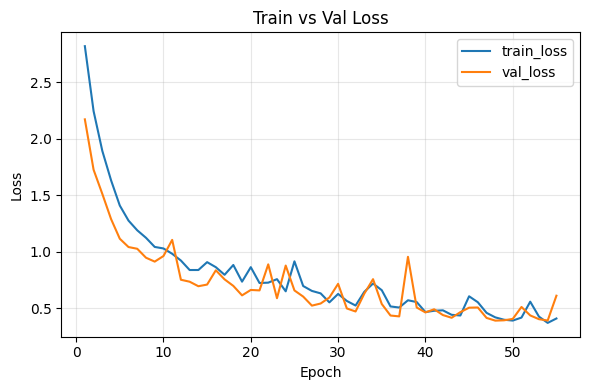

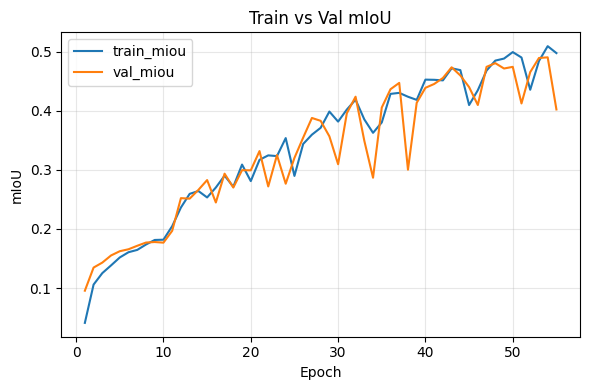

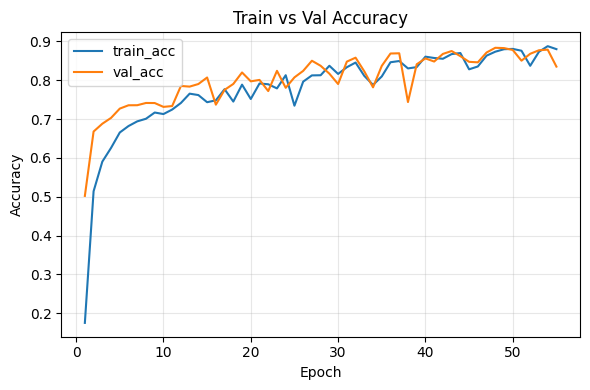

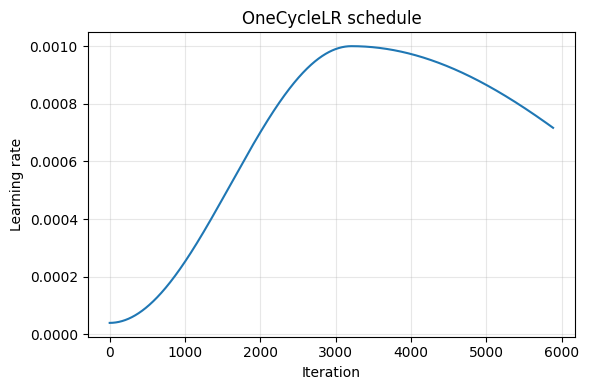

In [13]:
# load history if empty
if history_clean is None:
    history_filename = "safety_unet_mobilenet_history.json" if LEVELS_SEG else "unet_mobilenet_history.json"
    with open("checkpoints_unet_mobilenet/" + history_filename, "r", encoding="utf-8") as f:
        history_clean = json.load(f)

epochs = np.arange(1, len(history_clean["train_loss"]) + 1)

def plot_curves(train_key, val_key, ylabel, title):
    plt.figure(figsize=(6,4))
    plt.plot(epochs, history_clean[train_key], label=f"{train_key}")
    plt.plot(epochs, history_clean[val_key],   label=f"{val_key}")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 1) Loss
plot_curves("train_loss", "val_loss", "Loss", "Train vs Val Loss")

# 2) mIoU
plot_curves("train_miou", "val_miou", "mIoU", "Train vs Val mIoU")

# 3) Accuracy
plot_curves("train_acc", "val_acc", "Accuracy", "Train vs Val Accuracy")

# 4) Learning rate schedule
plt.figure(figsize=(6,4))
plt.plot(history_clean["lrs"])
plt.xlabel("Iteration")
plt.ylabel("Learning rate")
plt.title("OneCycleLR schedule")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Segmentation Evaluation

In [14]:
best_path = "safety-Unet-Mobilenet_v2_best.pth" if LEVELS_SEG else "Unet-Mobilenet_v2_best.pth"
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, best_path)

# -------------------------
# Load best model
# -------------------------
print("Loading best model from:", BEST_MODEL_PATH)
model_best = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model_best.to(DEVICE).eval()

Loading best model from: checkpoints_unet_mobilenet\Unet-Mobilenet_v2_best.pth


Unet(
  (encoder): MobileNetV2Encoder(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=(1

### Evaluate the ICG segmentation model

In [15]:
# -------------------------
# Build test dataset/loader (reuse existing tools)
# -------------------------
test_items = build_items_from_dir(TEST_IMAGES_DIR, MASKS_DIR)
print(f"Test samples: {len(test_items)}")
assert len(test_items) > 0, "No test samples found – check TEST_IMAGES_DIR and MASKS_DIR"

test_set = SemanticDatasetCID(test_items, MEAN, STD, transform=t_val)

Test samples: 40


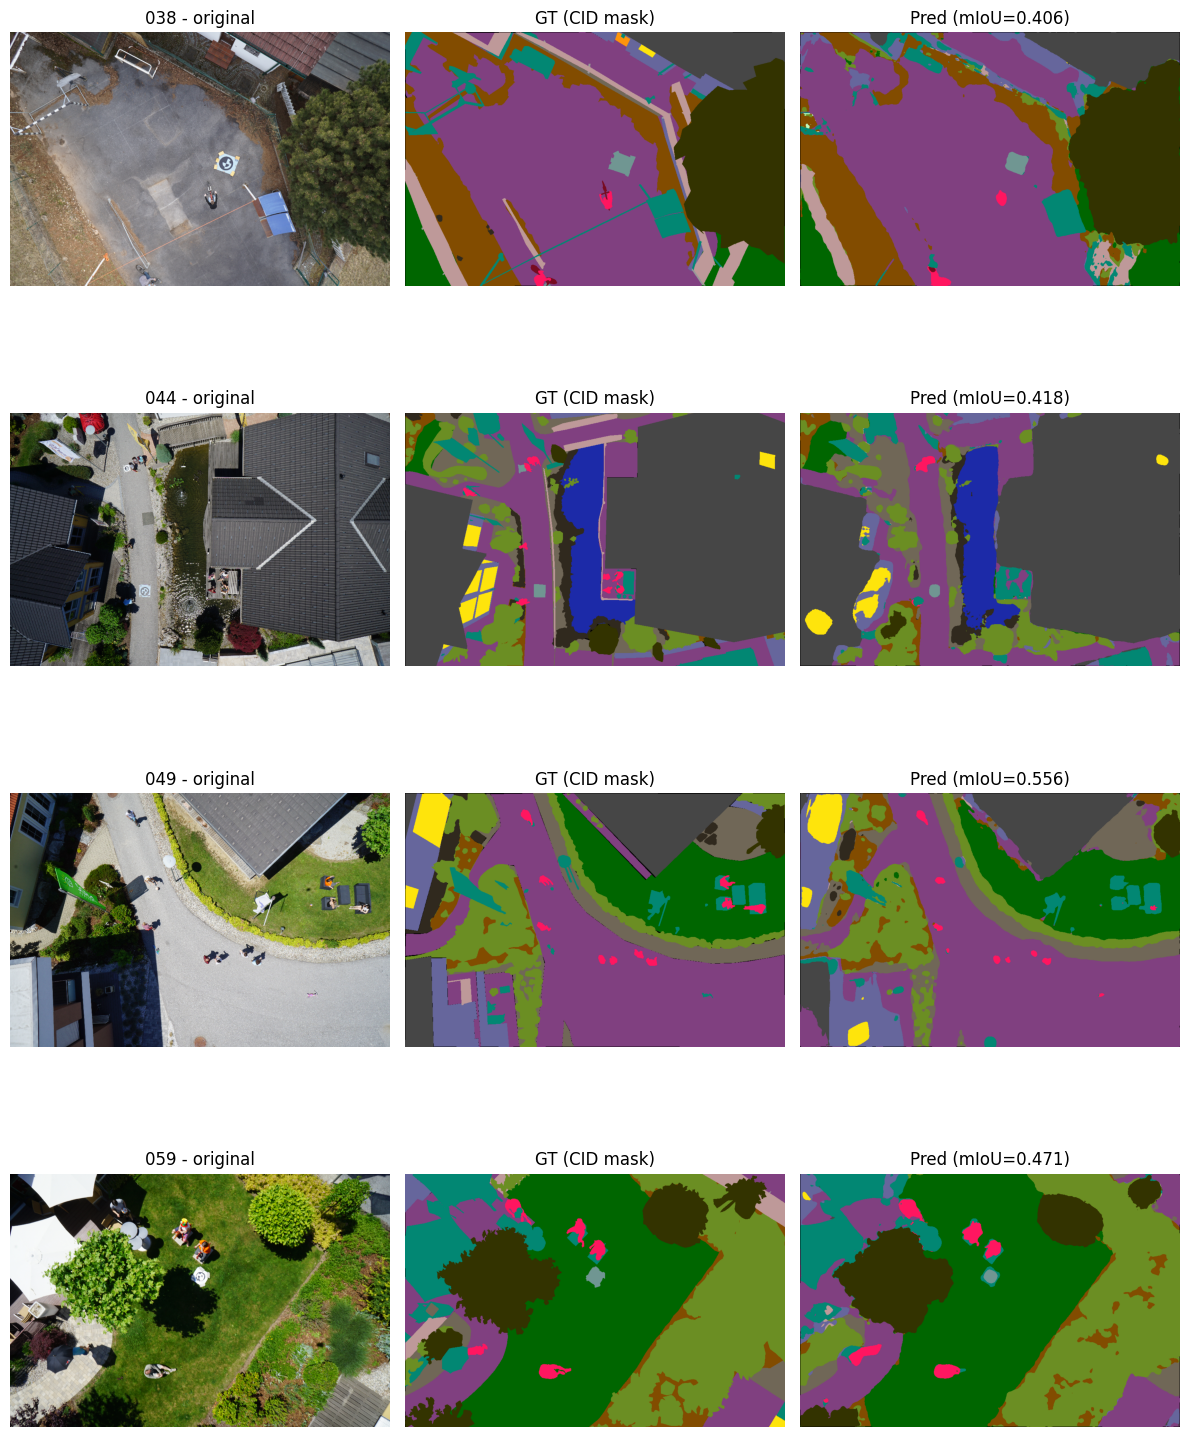

In [16]:
N_SHOW = 4  # how many test images to visualize

# -------------------------
# Color LUT for masks from CLASS_CSV
# -------------------------
df_classes = pd.read_csv(CLASS_CSV, skipinitialspace=True)
colors = df_classes[["r", "g", "b"]].values.astype("uint8")  # shape: [N_CLASSES, 3]
def colorize_mask(mask_np):
    """
    mask_np: (H,W) int CID
    returns: (H,W,3) uint8 RGB
    """
    mask_np = np.clip(mask_np, 0, len(colors) - 1)
    return colors[mask_np]

# -------------------------
# Visualize few samples
# -------------------------
fig, axes = plt.subplots(N_SHOW, 3, figsize=(12, 4 * N_SHOW))
if N_SHOW == 1:
    axes = np.expand_dims(axes, axis=0)  # make it [1,3] for indexing

for row_idx in range(N_SHOW):
    img_t, mask_t = test_set[row_idx]  # img_t: CHW normalized, mask_t: HW long
    stem = test_items[row_idx]["id"]

    # mIoU for this image
    img_batch = img_t.unsqueeze(0).to(DEVICE)
    mask_batch = mask_t.unsqueeze(0).to(DEVICE)

    with torch.inference_mode():
        logits = model_best(img_batch)
        miou_img = mIoU(logits, mask_batch, n_classes=N_CLASSES, ignore_index=IGNORE_IDX)

    # prediction
    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()
    gt   = mask_t.numpy()

    # de-normalize image for display
    img_np = img_t.cpu().numpy()  # C,H,W
    img_np = np.transpose(img_np, (1, 2, 0))  # H,W,C
    img_np = (img_np * np.array(STD) + np.array(MEAN))  # unnormalize
    img_np = np.clip(img_np, 0.0, 1.0)

    # colorize GT and pred
    gt_color   = colorize_mask(gt)
    pred_color = colorize_mask(pred)

    # Plot
    ax0, ax1, ax2 = axes[row_idx]

    ax0.imshow(img_np)
    ax0.set_title(f"{stem} - original")
    ax0.axis("off")

    ax1.imshow(gt_color)
    ax1.set_title("GT (CID mask)")
    ax1.axis("off")

    ax2.imshow(pred_color)
    ax2.set_title(f"Pred (mIoU={miou_img:.3f})")
    ax2.axis("off")

plt.tight_layout()
plt.show()


In [17]:
# =========================
# 8) Full evaluation on TEST set
# =========================

# DataLoader for test set
test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

# Loss (same as training)
criterion_test = nn.CrossEntropyLoss(ignore_index=IGNORE_IDX) if IGNORE_IDX is not None else nn.CrossEntropyLoss()

model_best.eval()

test_loss = 0.0
test_miou_accum = 0.0
test_acc_accum = 0.0

# confusion matrix for per-class IoU
conf_mat = np.zeros((N_CLASSES, N_CLASSES), dtype=np.int64)

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Test evaluation"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        logits = model_best(imgs)

        # loss + batch metrics
        loss = criterion_test(logits, masks)
        test_loss += loss.item()
        test_miou_accum += mIoU(logits, masks, N_CLASSES, IGNORE_IDX)
        test_acc_accum  += pixel_accuracy(logits, masks, IGNORE_IDX)

        # update confusion matrix
        preds = torch.argmax(logits, dim=1)

        preds_f = preds.view(-1).cpu()
        masks_f = masks.view(-1).cpu()

        if IGNORE_IDX is not None:
            valid = masks_f != IGNORE_IDX
            preds_f = preds_f[valid]
            masks_f = masks_f[valid]

        if preds_f.numel() == 0:
            continue

        idx = masks_f * N_CLASSES + preds_f
        binc = np.bincount(idx.numpy(), minlength=N_CLASSES**2)
        conf_mat += binc.reshape(N_CLASSES, N_CLASSES)

# ---- Aggregate metrics ----
num_batches = max(1, len(test_loader))
test_loss /= num_batches
test_miou = test_miou_accum / num_batches
test_acc  = test_acc_accum  / num_batches

tp = np.diag(conf_mat).astype(np.float64)
sum_rows = conf_mat.sum(axis=1).astype(np.float64)  # GT per class
sum_cols = conf_mat.sum(axis=0).astype(np.float64)  # Pred per class
union = sum_rows + sum_cols - tp

per_class_iou = tp / np.maximum(union, 1.0)
per_class_acc = tp / np.maximum(sum_rows, 1.0)

# ignore 'conflicting' in macro metrics
if IGNORE_IDX is not None:
    per_class_iou[IGNORE_IDX] = np.nan
    per_class_acc[IGNORE_IDX] = np.nan

mean_iou = np.nanmean(per_class_iou)
mean_acc = np.nanmean(per_class_acc)
overall_acc = tp.sum() / np.maximum(conf_mat.sum(), 1.0)

print("\n===== TEST SET METRICS =====")
print(f"Cross-entropy loss:                {test_loss:.4f}")
print(f"Batch-avg mIoU (mIoU fn):          {test_miou:.4f}")
print(f"Batch-avg pixel acc (pixel_acc):   {test_acc:.4f}")
print(f"Conf-matrix Mean IoU (macro):      {mean_iou:.4f}")
print(f"Conf-matrix Mean Acc (macro):      {mean_acc:.4f}")
print(f"Overall pixel accuracy (micro):    {overall_acc:.4f}")

# ---- Per-class table ----
rows = []
for cid, cname in enumerate(class_names):
    rows.append({
        "cid": cid,
        "class": cname,
        "pixels_gt": int(sum_rows[cid]),
        "IoU": float(per_class_iou[cid]) if not np.isnan(per_class_iou[cid]) else np.nan,
        "Acc": float(per_class_acc[cid]) if not np.isnan(per_class_acc[cid]) else np.nan,
    })

df_test_metrics = pd.DataFrame(rows)
print("\nPer-class metrics (NaN = class not present or ignored):")
display(df_test_metrics)


metrics_output_csv = "safety_test_metrics_per_class.csv" if LEVELS_SEG else "test_metrics_per_class.csv"
csv_path = os.path.join(OUTPUT_DIR, metrics_output_csv)
df_test_metrics.to_csv(csv_path, index=False)
print("\nPer-class metrics saved to:", csv_path)


Test evaluation:   0%|          | 0/14 [00:00<?, ?it/s]


===== TEST SET METRICS =====
Cross-entropy loss:                0.3835
Batch-avg mIoU (mIoU fn):          0.4917
Batch-avg pixel acc (pixel_acc):   0.8865
Conf-matrix Mean IoU (macro):      0.5047
Conf-matrix Mean Acc (macro):      0.6178
Overall pixel accuracy (micro):    0.8847

Per-class metrics (NaN = class not present or ignored):


,cid,class,pixels_gt,IoU,Acc
0,0,unlabeled,83193,0.266868,0.384948
1,1,paved-area,10391002,0.895436,0.968794
2,2,dirt,1030957,0.525707,0.676434
3,3,grass,6105170,0.927399,0.957024
4,4,gravel,2242651,0.731788,0.846834
5,5,water,265106,0.826791,0.922510
6,6,rocks,98735,0.298656,0.364754
7,7,pool,48812,0.264561,0.975908
8,8,vegetation,2188482,0.669687,0.807496
9,9,roof,3383424,0.905554,0.939336



Per-class metrics saved to: checkpoints_unet_mobilenet\test_metrics_per_class.csv


### Inference + Landing Selction

In [18]:
# =========================
# Safe landing spot selection on TEST set
# =========================

# 1) SAFE/UNSAFE mapping (class-based) – only used when LEVELS_SEG == False
if not LEVELS_SEG:
    SAFE, UNSAFE = 0, 1
    BASE_BY_NAME = {
        # very safe substrate (soft/stable)
        "grass": SAFE, "dirt": SAFE, "gravel": SAFE, "unlabeled": SAFE,

        # acceptable substrate but harder / more dynamic
        "paved-area": SAFE, "roof": SAFE, "ar-marker": SAFE,

        # static obstacles / non-landing / no risk on living beings.
        "rocks": UNSAFE, "wall": UNSAFE, "fence": UNSAFE, "fence-pole": UNSAFE,
        "vegetation": UNSAFE, "tree": UNSAFE, "bald-tree": UNSAFE, "obstacle": UNSAFE,
        "water": UNSAFE, "pool": UNSAFE, "window": UNSAFE, "door": UNSAFE,

        # hard exclusions: people/vehicles/unknown/conflicting etc.
        "person": UNSAFE, "dog": UNSAFE, "car": UNSAFE, "bicycle": UNSAFE,
        "conflicting": UNSAFE,
    }

    NAME2CID = {name.lower(): i for i, name in enumerate(class_names)}
    SAFE_CIDS   = {NAME2CID[n] for n, cat in BASE_BY_NAME.items()
                   if cat == SAFE   and n in NAME2CID}
    UNSAFE_CIDS = {NAME2CID[n] for n, cat in BASE_BY_NAME.items()
                   if cat == UNSAFE and n in NAME2CID}
    print("SAFE CIDs:", sorted(SAFE_CIDS))
    print("UNSAFE CIDs:", sorted(UNSAFE_CIDS))
else:
    SAFE_CIDS = None   # not used in levels mode
    UNSAFE_CIDS = None

# 2) Preprocess helper (shared)
def preprocess_image_cv2_to_tensor(img_rgb):
    # Resize to training size (bilinear) and normalize with ImageNet stats
    aug = A.Resize(IMG_H, IMG_W, interpolation=cv2.INTER_LINEAR, always_apply=True)
    img_resized = aug(image=img_rgb)["image"]
    pil = Image.fromarray(img_resized)
    tf = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
    return tf(pil), img_resized  # CHW tensor + resized RGB

# 3) Selection helpers: class-based vs levels-based
def pick_safest_point_classes(pred_cls_hw, safe_cids, force_border_if_all_safe=True):
    """
    pred_cls_hw: (H, W) np.int64 predicted class indices
    Returns (y_resized, x_resized, dist_px_resized, note, safe_ratio)
    """
    safe_mask = np.isin(pred_cls_hw, list(safe_cids)).astype(np.uint8)  # 1=safe, 0=unsafe
    h, w = safe_mask.shape
    note = "ok"
    safe_ratio = float(safe_mask.mean())

    if safe_mask.max() == 0:
        return None, None, 0.0, "no_safe_pixels", safe_ratio

    sm = safe_mask
    if safe_mask.min() == 1:
        if force_border_if_all_safe:
            sm = safe_mask.copy()
            sm[0, :] = 0; sm[-1, :] = 0; sm[:, 0] = 0; sm[:, -1] = 0
            note = "no_unsafe_predicted; used_border_as_unsafe"
        else:
            yc, xc = h // 2, w // 2
            return yc, xc, min(h, w) / 2.0, "no_unsafe_predicted; picked_center", safe_ratio

    dt = cv2.distanceTransform(sm, distanceType=cv2.DIST_L2, maskSize=3)
    y, x = np.unravel_index(np.argmax(dt), dt.shape)
    return int(y), int(x), float(dt[y, x]), note, safe_ratio

def pick_safest_point_levels(pred_levels_hw, force_border_if_all_safe=True):
    """
    pred_levels_hw: (H, W) np.int64 in {0,1,2,3}
    Goal: pick the pixel with the **highest available level (3 or 2)**
    that is **furthest** from any pixel with level <= 1.
    Returns (y_resized, x_resized, dist_px_resized, note, safe_ratio_level_ge2)
    """
    levels = pred_levels_hw
    h, w = levels.shape

    # Safe candidates: level >= 2
    safe_mask = (levels >= 2).astype(np.uint8)
    hazard_mask = (levels <= 1).astype(np.uint8)  # level 0 or 1

    safe_ratio = float(safe_mask.mean())
    if safe_mask.max() == 0:
        return None, None, 0.0, "no_level>=2_pixels", safe_ratio

    cand3 = (levels == 3).astype(np.uint8)
    cand2 = (levels == 2).astype(np.uint8)

    note = "ok"

    # Handle degenerate case: no hazard pixels (all >=2)
    if hazard_mask.max() == 0:
        if force_border_if_all_safe:
            hz = hazard_mask.copy()
            hz[0, :] = 1; hz[-1, :] = 1; hz[:, 0] = 1; hz[:, -1] = 1
            dt_mask = (hz == 0).astype(np.uint8)  # 1 = non-hazard, 0 = pseudo-hazard (border)
            note = "no_hazard_levels; used_border_as_hazard"
        else:
            yc, xc = h // 2, w // 2
            lvl_here = int(levels[yc, xc])
            return yc, xc, 0.0, f"no_hazard_levels; picked_center_L{lvl_here}", safe_ratio
    else:
        dt_mask = safe_mask  # 1 where level>=2, 0 where hazard (<=1)

    dt = cv2.distanceTransform(dt_mask, distanceType=cv2.DIST_L2, maskSize=3)

    # Prefer level 3 if present
    if cand3.max() > 0:
        dt3 = dt * cand3
        y, x = np.unravel_index(np.argmax(dt3), dt3.shape)
        dist = float(dt3[y, x])
        note2 = note + "; used_L3"
        return int(y), int(x), dist, note2, safe_ratio

    # Otherwise fall back to level 2
    dt2 = dt * cand2
    if dt2.max() == 0:
        # Shouldn't really happen if safe_mask has level 2s, but be defensive
        ys, xs = np.where(safe_mask > 0)
        if len(ys) == 0:
            return None, None, 0.0, "no_safe_pixels_after_candidates", safe_ratio
        mid = len(ys) // 2
        return int(ys[mid]), int(xs[mid]), 0.0, "fallback_safe_pixel", safe_ratio

    y, x = np.unravel_index(np.argmax(dt2), dt2.shape)
    dist = float(dt2[y, x])
    note2 = note + "; used_L2"
    return int(y), int(x), dist, note2, safe_ratio

# 4) Iterate test images, run inference + selection
image_paths = list_images(TEST_IMAGES_DIR)
assert len(image_paths) > 0, f"No images found in {TEST_IMAGES_DIR}"
print(f"Evaluating {len(image_paths)} images from: {TEST_IMAGES_DIR}")

results = []

for img_path in tqdm(image_paths, desc="Safe-landing inference"):
    img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        print("[warn] cannot read:", img_path)
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H0, W0 = img_rgb.shape[:2]

    start = time.perf_counter()

    x_t, img_resized_rgb = preprocess_image_cv2_to_tensor(img_rgb)
    x = x_t.unsqueeze(0).to(DEVICE, non_blocking=True)

    with torch.inference_mode():
        logits = model_best(x)  # [1, C, H, W]
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
    pred = logits.argmax(dim=1).squeeze(0).detach().cpu().numpy().astype(np.int64)

    if LEVELS_SEG:
        y_r, x_r, dist_px, note, safe_ratio = pick_safest_point_levels(
            pred, force_border_if_all_safe=True
        )
    else:
        y_r, x_r, dist_px, note, safe_ratio = pick_safest_point_classes(
            pred, SAFE_CIDS, force_border_if_all_safe=True
        )

    # Map selected point back to original-resolution coordinates
    if y_r is not None and x_r is not None:
        x_orig = int(round(x_r * (W0 / float(IMG_W))))
        y_orig = int(round(y_r * (H0 / float(IMG_H))))
        x_orig = int(np.clip(x_orig, 0, W0 - 1))
        y_orig = int(np.clip(y_orig, 0, H0 - 1))
    else:
        x_orig = None
        y_orig = None

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - start) * 1000.0

    image_id = os.path.splitext(os.path.basename(img_path))[0]
    results.append({
        "id": image_id,
        "x": x_orig, "y": y_orig,                    # original-resolution coords
        "x_resized": x_r, "y_resized": y_r,         # coords in (IMG_W, IMG_H) space
        "distance_px_resized": dist_px,             # DT value in resized grid
        "safe_ratio_resized": safe_ratio,
        "elapsed_ms_total": elapsed_ms,
        "note": note,
        "image_path": img_path,
        "H_orig": H0, "W_orig": W0
    })

# 5) Save CSV + print timing
df = pd.DataFrame(results)

csv_min = os.path.join(OUTPUT_DIR, "safe_land_spots_test.csv")
df[["id", "x", "y"]].to_csv(csv_min, index=False)
print("Saved landing spots (id,x,y) to:", csv_min)

if len(df):
    avg_ms = df["elapsed_ms_total"].mean()
    fps = 1000.0 / avg_ms if avg_ms > 0 else float("inf")
    print(f"\nAverage end-to-end time (inference + selection): {avg_ms:.2f} ms/image  (~{fps:.2f} FPS)")


SAFE CIDs: [0, 1, 2, 3, 4, 9, 21]
UNSAFE CIDs: [5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23]
Evaluating 40 images from: ../Data/training_set/slz_out/det_obb/splits_yolo_obb\images\test


Safe-landing inference:   0%|          | 0/40 [00:00<?, ?it/s]

Saved landing spots (id,x,y) to: checkpoints_unet_mobilenet\safe_land_spots_test.csv

Average end-to-end time (inference + selection): 70.95 ms/image  (~14.09 FPS)


## Evaluation of Landing Spot Selection Metrics

In [1]:
# =========================
# Evaluate landing-kernel metrics for segmentation predictions
# Reads predictions/*.csv  (each: image_id/id, x, y in original pixels)
# =========================
import numpy as np
import pandas as pd
import csv
import cv2
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

# ----- Parameters: landing kernel & thresholds -----
D_M = 0.40
DELTA_POS_M = 0.80
RADIUS_M = D_M / 2.0 + DELTA_POS_M    # 1.0 m default

PURITY_MIN_SLS       = 0.90           # SLS success threshold on safe purity
FSR_HAZARD_FRAC_MIN  = 0.03           # 3% hazard overlap → FSR failure

# ----- Camera/GSD (avoid name clash with training IMG_W) -----
CAMERA_IMG_W_PX   = 6000       # native photo width (px)
SENSOR_W_MM       = 23.5
ASSUMED_FOCAL_MM  = 16.0
PX_SIZE_MM        = SENSOR_W_MM / CAMERA_IMG_W_PX  # mm/px (horizontal)


# ---- Paths ----
PREDICTIONS_DIR = Path("predictions")  # contains [ModelName].csv with columns id,x,y (original px)
LEVELS_DIR      = Path("../Data/training_set/slz_out/masks_levels")  # GT levels masks
OUTPUT_SUMMARY  = Path("./seg_kernel_eval_summary.csv")
ALTS_CSV = Path("../Data/training_set/slz_out/altitude/altitudes_final.csv")
TEST_LBL_DIR   = Path("../Data/training_set/slz_out/det_obb/splits_yolo_obb/labels/test").resolve()

assert ALTS_CSV.exists(), f"Missing altitudes CSV: {ALTS_CSV}"
assert PREDICTIONS_DIR.exists(), f"Missing predictions folder: {PREDICTIONS_DIR.resolve()}"
assert LEVELS_DIR.exists(), f"Missing levels masks folder: {LEVELS_DIR.resolve()}"

# --------- COLLECT TEST IDS ----------
test_ids = sorted([p.stem for p in TEST_LBL_DIR.glob("*.txt")])
assert test_ids, f"No test label files found in {TEST_LBL_DIR}"
print(f"Evaluating on {len(test_ids)} test IDs.")

# ----- Load altitudes → per-image GSD -----
def gsd_from_altitude_m(alt_m: float) -> float:
    """Ground sampling distance (m/px) from altitude in meters."""
    return alt_m * (PX_SIZE_MM / ASSUMED_FOCAL_MM)

def load_GSDs(csv_path: Path) -> dict[str, float]:
    gsd = {}
    with open(csv_path, newline="") as f:
        for row in csv.DictReader(f, skipinitialspace=True):
            img_id = row["image_id"].strip()
            H = float(row["final_alt_m"])
            gsd[img_id] = gsd_from_altitude_m(H)
    return gsd

GSD_BY_ID = load_GSDs(ALTS_CSV)

# ---- Helpers ----
def disc_mask(H, W, cx, cy, r_px):
    m = np.zeros((H, W), np.uint8)
    cv2.circle(m, (int(round(cx)), int(round(cy))), int(round(r_px)), 1, -1)
    return m

def load_levels(stem: str) -> np.ndarray:
    p = LEVELS_DIR / f"{stem}_levels.png"   # exact naming as requested
    if not p.exists():
        raise FileNotFoundError(f"Levels mask not found: {p}")
    m = np.array(Image.open(p))
    if m.ndim == 3:  # just in case a paletted PNG gets loaded as RGB
        m = m[..., 0]
    return m.astype(np.uint8)

def load_pred_csv(csv_path: Path) -> dict[str, tuple[int,int]]:
    df = pd.read_csv(csv_path)
    # Flexible id column (prefer 'id', but accept 'image_id'/'image'/'stem')
    id_col = None
    for c in ("id", "image_id", "image", "stem"):
        if c in df.columns:
            id_col = c; break
    if id_col is None or not {"x","y"}.issubset(df.columns):
        raise ValueError(f"{csv_path.name} must contain id/x/y (or image_id).")
    preds = {}
    for _, r in df.iterrows():
        stem = str(Path(str(r[id_col])).stem)  # tolerate paths
        if pd.isna(r["x"]) or pd.isna(r["y"]): 
            continue
        preds[stem] = (int(round(float(r["x"]))), int(round(float(r["y"]))))
    return preds

# ---- Build minimal GT cache (levels, safe2) ----
gt_cache = {}
missing = []
for stem in test_ids:
    try:
        levels = load_levels(stem)
    except FileNotFoundError:
        missing.append(stem)
        continue
    safe2 = (levels >= 2).astype(np.uint8)          # S>=2 considered 'safe' for purity
    gt_cache[stem] = {"levels": levels, "safe2": safe2, "H": levels.shape[0], "W": levels.shape[1]}

if missing:
    print(f"[warn] {len(missing)} test images missing levels masks. First 5:", missing[:5])

# ---- Evaluate all model CSVs ----
summaries = []
csv_files = sorted(PREDICTIONS_DIR.glob("*.csv"))
assert csv_files, f"No CSVs found under {PREDICTIONS_DIR.resolve()}"

print(f"Landing-kernel radius: {RADIUS_M:.2f} m")
for csv_path in csv_files:
    model_name = csv_path.stem
    preds = load_pred_csv(csv_path)

    total_images   = len(test_ids)          # denominator for SLS_L2
    selected_count = 0                      # images with a usable pred (point inside image & A>0)
    sls_success    = 0                      # purity >= PURITY_MIN_SLS
    fsr_fail       = 0                      # hazard fraction >= FSR_HAZARD_FRAC_MIN
    purity_sum     = 0.0
    hfrac_sum      = 0.0

    for stem in tqdm(test_ids, desc=model_name, leave=False):
        if stem not in gt_cache:
            continue
        if stem not in preds:
            # No pred → SLS failure; do not count in FSR denominator (matches OBB logic)
            continue

        levels = gt_cache[stem]["levels"]
        safe2  = gt_cache[stem]["safe2"]
        H, W   = gt_cache[stem]["H"], gt_cache[stem]["W"]
        hazard0 = (levels == 0).astype(np.uint8)

        # Radius in pixels from per-image GSD
        if stem not in GSD_BY_ID:
            raise KeyError(f"GSD missing for '{stem}'. Ensure altitudes CSV covers all test images.")
        r_px = RADIUS_M / max(GSD_BY_ID[stem], 1e-9)

        # Center from predictions (clamped)
        cx, cy = preds[stem]
        if cx < 0 or cy < 0 or cx >= W or cy >= H:
            continue
        D = disc_mask(H, W, cx, cy, r_px)
        A = int(D.sum())
        if A == 0:
            continue

        selected_count += 1

        # Purity vs S>=2
        p = float((D & safe2).sum()) / float(A)
        purity_sum += p
        if p >= PURITY_MIN_SLS:
            sls_success += 1

        # Hazard overlap vs S==0
        hfrac = float((D & hazard0).sum()) / float(A)
        hfrac_sum += hfrac
        if hfrac >= FSR_HAZARD_FRAC_MIN:
            fsr_fail += 1

    SLS_L2     = sls_success / total_images   if total_images   > 0 else 0.0
    FSR        = fsr_fail    / selected_count if selected_count > 0 else 0.0
    avg_purity = purity_sum  / selected_count if selected_count > 0 else 0.0
    avg_hfrac  = hfrac_sum   / selected_count if selected_count > 0 else 0.0

    summaries.append(dict(
        model=model_name,
        images=total_images,
        selected=selected_count,
        SLS_L2=round(SLS_L2, 4),
        FSR=round(FSR, 4),
        avg_sel_purity=round(avg_purity, 4),
        avg_sel_hfrac=round(avg_hfrac, 4),
        radius_m=RADIUS_M
    ))

# ---- Print & save summary ----
cols = ["model","images","selected","SLS_L2","FSR","avg_sel_purity","avg_sel_hfrac","radius_m"]
hdr = " | ".join([f"{c:>16s}" for c in cols])
print("\n" + hdr)
print("-"*len(hdr))
for s in sorted(summaries, key=lambda d: d["SLS_L2"], reverse=True):
    print(" | ".join([f"{str(s[c]):>16s}" for c in cols]))

pd.DataFrame(summaries)[cols].to_csv(OUTPUT_SUMMARY, index=False)
print("\nSaved summary to:", OUTPUT_SUMMARY.resolve())

Evaluating on 40 test IDs.
Landing-kernel radius: 1.00 m


ICG-MobileNet-UNet-10:   0%|          | 0/40 [00:00<?, ?it/s]

ICG-MobileNet-UNet-100:   0%|          | 0/40 [00:00<?, ?it/s]

Safe-MobileNet-UNet-10:   0%|          | 0/40 [00:00<?, ?it/s]

Safe-MobileNet-UNet-100:   0%|          | 0/40 [00:00<?, ?it/s]


           model |           images |         selected |           SLS_L2 |              FSR |   avg_sel_purity |    avg_sel_hfrac |         radius_m
-----------------------------------------------------------------------------------------------------------------------------------------------------
ICG-MobileNet-UNet-10 |               40 |               34 |              0.8 |           0.0588 |           0.9666 |           0.0055 |              1.0
ICG-MobileNet-UNet-100 |               40 |               34 |              0.8 |           0.0588 |            0.958 |           0.0049 |              1.0
Safe-MobileNet-UNet-100 |               40 |               34 |            0.775 |           0.0588 |           0.9417 |           0.0085 |              1.0
Safe-MobileNet-UNet-10 |               40 |               34 |             0.65 |           0.0294 |           0.8575 |           0.0052 |              1.0

Saved summary to: E:\Documents\updated uni work\KU PhD\Research\Projects\S